# BERTopic for topic modelling

Welcome back!
<br>

<img src="https://raw.githubusercontent.com/MaartenGr/BERTopic/master/images/logo.png" width="40%">

# RECAP

In the previous session, we worked with a dataset of tweets collected from the Office of the United Nations High Commissioner for Human Rights (2017–2022). The aim was not to test predefined categories, but to explore what themes emerge from the data using topic modelling.

We began by setting up the environment and downloading the dataset. Because the original file contained a formatting issue around a specific row, we imported it in two parts and reconstructed a clean version of the dataset. This step highlighted a practical point: real-world data often requires manual inspection and adjustment before analysis.

We then focused on text preprocessing. Rather than applying a single cleaning step, we constructed a pipeline of functions to:

remove emojis,
strip URLs and mentions,
clean hashtags,
remove noisy characters,
and standardise spacing.

This allowed us to move from raw social media text to a more consistent representation suitable for modelling.

After preprocessing, we filtered the dataset to English-language tweets and created a cleaned text column. These cleaned texts formed the input to our topic model.

We then introduced BERTopic and fitted the model using:

a sentence transformer (all-mpnet-base-v2) to generate embeddings,
UMAP to reduce dimensionality,
and a keyphrase-based vectorizer to improve topic representation.

This pipeline allowed us to move from individual tweets to clusters of semantically similar texts.

Finally, we explored the outputs of the model by:

inspecting topic frequencies,
examining top terms within topics,
and looking at representative documents.

At this stage, the focus was on understanding what the model produces and how topics are constructed.

# This Week...
In this session, we move from generating topics to working more closely with the model outputs.

We focus on how to interpret topics in a more systematic way, going beyond simple inspection of top words. This includes examining topic composition, comparing topics, and identifying patterns in how documents are grouped.

We also make use of visualisations to better understand the structure of the model and how topics relate to one another.

Finally, we consider ways to improve topic quality in practice. This includes adjusting model components and discussing extensions, such as adapting embedding models to better fit specific datasets.

In [69]:
import subprocess
import sys
from importlib.metadata import distributions

packages = [
    "bertopic",
    "hdbscan",
    "keyphrase_vectorizers",
    "nbformat",
    "emoji"
]

installed = {dist.metadata["Name"].lower() for dist in distributions()}
missing = [pkg for pkg in packages if pkg.lower() not in installed]

print(missing)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])


['keyphrase_vectorizers']


In [70]:
import locale
import pandas as pd
import re
import emoji
import string
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from keyphrase_vectorizers import KeyphraseCountVectorizer
locale.getpreferredencoding = lambda: "UTF-8"

# Reload Data and Model
We briefly rerun the first session so the model and its outputs are available for inspection.

In [71]:
# Reload the data
!curl -O https://raw.githubusercontent.com/world-politics-datalab/un_hum_rights_office_tweets/main/un_office_humrights_tweets_sept4_2017_sept3_2022.csv

# Preprocess the data
data = pd.read_csv("un_office_humrights_tweets_sept4_2017_sept3_2022.csv", header=0, nrows=4037, encoding='utf-8',  quotechar='"')
data = data.iloc[:,:88]

!tail -n 17130 un_office_humrights_tweets_sept4_2017_sept3_2022.csv > temp.csv

data2 = pd.read_csv("temp.csv", encoding='utf-8',  quotechar='"', header=None)
data2.drop(data2.columns[[14, 15]], axis=1, inplace=True)

data2 = pd.DataFrame(data=data2.values, columns=data.columns)

# data_all = data.append(data2,ignore_index=True) # version for use with older versions of pandas

df = pd.concat((data, data2), ignore_index=True)
df.to_csv("un_tweets_corrected.csv", encoding='utf-8')

def strip_emoji(text):
    """
    Remove all emoji characters from the text.
    Using the emoji package to safely filter emojis.
    """
    return emoji.replace_emoji(text, replace="")

def strip_all_entities(text):
    """
    Clean links, mentions, ASCII noise, punctuation,
    and convert the text to lowercase.
    """
    # Remove newline characters and lowercase text
    text = text.replace("\r", "").replace("\n", " ").lower()

    # Remove mentions (@username) and URLs
    text = re.sub(r"(?:\@|https?\://)\S+", "", text)

    # Remove non-ASCII characters (e.g., stray corrupted bytes)
    text = re.sub(r"[^\x00-\x7f]", r"", text)

    # Remove punctuation and special characters
    banned_list = string.punctuation + "Ã" + "±" + "ã" + "¼" + "â" + "»" + "§"
    table = str.maketrans("", "", banned_list)
    text = text.translate(table)

    return text

def clean_hashtags(tweet):
    """
    Remove trailing hashtags entirely,
    but keep words that have '#' inside the sentence by removing the '#'.
    """
    # Remove hashtags at the end of the sentence
    new_tweet = " ".join(
        word.strip()
        for word in re.split(
            r"#(?!(?:hashtag)\b)[\w-]+(?=(?:\s+#[\w-]+)*\s*$)", tweet
        )
    )
    # Remove the '#' symbol for inline hashtags
    new_tweet2 = " ".join(word.strip() for word in re.split("#|_", new_tweet))
    return new_tweet2

def filter_chars(text):
    """
    Remove words containing '$' or '&' characters.
    These symbols often appear in corrupted text or ads.
    """
    cleaned = []
    for word in text.split(" "):
        if ("$" in word) or ("&" in word):
            cleaned.append("")  # remove word
        else:
            cleaned.append(word)
    return " ".join(cleaned)

def remove_mult_spaces(text):
    """
    Replace multiple spaces with a single space.
    Ensures clean and consistent spacing.
    """
    return re.sub(r"\s\s+", " ", text)

    # select only English data
en_data = df.loc[df['lang'] == "en"]

clean_texts = []
for t in en_data["text"]:
    cleaned = strip_emoji(t)                 # 1. remove emojis
    cleaned = strip_all_entities(cleaned)    # 2. remove URLs, mentions, punctuation
    cleaned = clean_hashtags(cleaned)        # 3. clean hashtag patterns
    cleaned = filter_chars(cleaned)          # 4. remove unwanted symbols ($, &)
    cleaned = remove_mult_spaces(cleaned)    # 5. collapse multiple spaces
    clean_texts.append(cleaned)

en_data["text_clean"] = clean_texts
docs = list(en_data["text_clean"])


# Training the Model

# 01 - Text representation (create embeddings)
# See: https://huggingface.co/sentence-transformers
embedding_model = "all-mpnet-base-v2"

# 02 - Reduce dimensionality (UMAP)
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# 03 - Cluster reduced embeddings
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# 04 - Topic representation
vectorizer_model = KeyphraseCountVectorizer(max_df = int(0.5*len(docs)),min_df = 5, decay = 0.1, delete_min_df=5.0)

# 05 - Create topic
#ctfidf_model = ClassTfidfTransformer()

# 06 - (Optional) Fine-tune topic representations with
# a `bertopic.representation` model
#representation_model = KeyBERTInspired()


# NOTE: earlier versions of KeyphraseCountVectorizer do not use the `decay` and `delete_min_df` params
try: # works with KeyphraseCountVectorizer v0.13
    topic_model = BERTopic(embedding_model="all-mpnet-base-v2",
                           umap_model = umap_model,
                           hdbscan_model= hdbscan_model,
                           vectorizer_model= vectorizer_model,
                           language="english",
                           calculate_probabilities=True,
                           verbose=True,
                        )
except TypeError: # in case of older version of KeyphraseCountVectorizer
    topic_model = BERTopic(embedding_model="all-mpnet-base-v2",
                           umap_model = umap_model,
                           hdbscan_model= hdbscan_model,
                           vectorizer_model=KeyphraseCountVectorizer(max_df = int(0.5*len(docs)), min_df = 5),
                           language="english",
                           calculate_probabilities=True,
                           verbose=True,
                        )

# =============================
# Fit the data on the model
# =============================

topics, probs = topic_model.fit_transform(docs)


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 11.8M  100 11.8M    0     0  12.4M      0 --:--:-- --:--:-- --:--:-- 12.4M


2026-04-07 11:49:05,546 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/249 [00:00<?, ?it/s]

2026-04-07 11:49:42,214 - BERTopic - Embedding - Completed ✓
2026-04-07 11:49:42,215 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 11:50:01,464 - BERTopic - Dimensionality - Completed ✓
2026-04-07 11:50:01,466 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 11:50:05,267 - BERTopic - Cluster - Completed ✓
2026-04-07 11:50:05,273 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 11:50:39,267 - BERTopic - Representation - Completed ✓


# Interpreting Topics
Now we are back at where we left last week.
Let's recheck how topics are distributed. We can start by looking at which topics are most frequent and how much of the data they capture.

In [72]:
# Overview of topics
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2254,-1_human_human rights_rights_amp,"[human, human rights, rights, amp, humanrights...",[has donated 988k to support our offices human...
1,0,207,0_standup4migrants_migrants_migration_migrant,"[standup4migrants, migrants, migration, migran...",[the reality is that theres more that unites u...
2,1,190,1_myanmar_rohingya_military_bangladesh,"[myanmar, rohingya, military, bangladesh, retu...",[myanmar alongside episodic violence a campaig...
3,2,167,2_lgbti_love_identity_sexual orientation,"[lgbti, love, identity, sexual orientation, pe...",[lets build a world where everyone is free equ...
4,3,145,3_torture_prevention_victims_illtreatment,"[torture, prevention, victims, illtreatment, b...",[torture can never be allowed or justified tho...
...,...,...,...,...,...
116,115,16,115_article_udhr70_life_art,"[article, udhr70, life, art, liberty, religion...",[article 6 applies across the entire spectrum ...
117,116,16,116_hatespeech_hate_hate speech_speech,"[hatespeech, hate, hate speech, speech, social...",[starts today minoritiesforumeurope to address...
118,117,16,117_climate_climate action_women amp girls_amp...,"[climate, climate action, women amp girls, amp...",[climatechange has specific adverse impacts on...
119,118,15,118_peaceful assembly_algeria_assembly_associa...,"[peaceful assembly, algeria, assembly, associa...",[un expert welcomes tunisias efforts to shore ...


In [73]:
# Inspect a specific topic (keywords)
topic_model.get_topic(1)

[('myanmar', np.float64(0.10822747569858195)),
 ('rohingya', np.float64(0.06334519109225359)),
 ('military', np.float64(0.023649386543151133)),
 ('bangladesh', np.float64(0.02311104110083898)),
 ('return', np.float64(0.019292621560267797)),
 ('crimes', np.float64(0.017047875667764428)),
 ('hrc38', np.float64(0.016490619481429658)),
 ('genocide', np.float64(0.013263677322684114)),
 ('refugees', np.float64(0.012470474645511997)),
 ('zeid', np.float64(0.012453829215528327))]

In [74]:
# Inspect representative documents
topic_model.representative_docs_

{-1: ['has donated 988k to support our offices humanrights work you can donate too',
  'has donated 35k to support our offices humanrights work you can donate too',
  'has donated 22k to support our offices humanrights work you can donate too'],
 0: ['the reality is that theres more that unites us than divides us says its time to change the narrative on migrants and refugees watch her story and read more here standup4migrants worldrefugeeday withrefugees',
  'its time to change the story on migration find out more about our toolbox created to rethink and change the way we talk about migrants and refugees standup4migrants withrefugees worldrefugeeday',
  'fiona servaes own experience as a migrant has led her to her work today advocating for narrative change on migration issues read her story standup4migrants'],
 1: ['myanmar alongside episodic violence a campaign to erode the legal personality and rights of the rohingya has steadily intensified since 1978 un human rights chief zeid at h

# Comparing Topics

We can compare topics qualitatively by inspecting the keywords in each

In [75]:
topic_model.get_topic(3)

[('torture', np.float64(0.13660025010099816)),
 ('prevention', np.float64(0.03815833914546664)),
 ('victims', np.float64(0.03549511024159144)),
 ('illtreatment', np.float64(0.03453509331062144)),
 ('body', np.float64(0.034146437373079486)),
 ('endtorture', np.float64(0.02621895978312435)),
 ('detention', np.float64(0.026116602389423735)),
 ('prisons', np.float64(0.02584698404249302)),
 ('fund', np.float64(0.02472836880240246)),
 ('liberty', np.float64(0.023416197721131984))]

In [76]:
topic_model.get_topic(7)

[('womens', np.float64(0.046851652666783726)),
 ('women', np.float64(0.0464741711207824)),
 ('gender', np.float64(0.04171988510613027)),
 ('generationequality', np.float64(0.04045054128159532)),
 ('gender equality', np.float64(0.038712208390737815)),
 ('istandwithher', np.float64(0.035238687634764086)),
 ('equality', np.float64(0.02957982337095208)),
 ('iwd2021', np.float64(0.025198151374455312)),
 ('leadership', np.float64(0.022063931608142903)),
 ('orangetheworld', np.float64(0.020525154646421462))]

In [77]:
topic_model.get_representative_docs(3)

['torture can never be allowed or justified those who commit acts of torture should be prosecuted anywhere in addition torture victims have a right to rehabilitation amp redress standup4humanrights',
 'torture leaves victims vulnerable with deep physical and emotional scars through the un torture fund professionals from various fields deliver essential liferestoring redress and rehabilitation for torture survivors antitorturefund40 redressfromtorture',
 'torture during interrogations is illegal immoral and ineffective']

In [78]:
topic_model.get_representative_docs(7)

['together we can make 2021 a landmark year for gender equality but only if we all actforequal on iwd2021 and in the leadup to the generationequality forum join us in taking action for an equal future',
 'the future is equal free from stigma stereotypes amp harmful gender norms the future is free from violence against women amp girls the future is better with women at the table the future begins today on iwd2021 with womens leadership generationequality',
 'on womensday join us to change discriminatory narrative and take action for womens rights and gender equality istandwithher changethestory u0001f449']

## Concept ~ Topic
We can quantitatively inspect topics that have the closest similarity to a concept using BERTopic's built in similarity.


In [79]:
# Below is an example of how we can find topics that are closer to the concept of 'torture'.
similar_topics, similarity = topic_model.find_topics("torture", top_n=5)
similar_topics, similarity


([3, 99, 42, 91, 41],
 [np.float32(0.59398484),
  np.float32(0.37306184),
  np.float32(0.3703342),
  np.float32(0.35821876),
  np.float32(0.33407313)])

In [80]:
for topic in similar_topics:
    print(topic_model.get_topic(topic))

[('torture', np.float64(0.13660025010099816)), ('prevention', np.float64(0.03815833914546664)), ('victims', np.float64(0.03549511024159144)), ('illtreatment', np.float64(0.03453509331062144)), ('body', np.float64(0.034146437373079486)), ('endtorture', np.float64(0.02621895978312435)), ('detention', np.float64(0.026116602389423735)), ('prisons', np.float64(0.02584698404249302)), ('fund', np.float64(0.02472836880240246)), ('liberty', np.float64(0.023416197721131984))]
[('practice', np.float64(0.08203786800387843)), ('girls', np.float64(0.0692213251010943)), ('hrc47', np.float64(0.04035842539733248)), ('women', np.float64(0.037437959504941366)), ('violation', np.float64(0.036105758927279144)), ('human rights violation', np.float64(0.02733503402919862)), ('disabilities', np.float64(0.026910858648926422)), ('fundamental rights', np.float64(0.026367691516368905)), ('health', np.float64(0.02537046342899607)), ('amp girls', np.float64(0.025152613330840366))]
[('deathpenalty', np.float64(0.1739

Similarity scores can be interpreted as:
closer to 1-> very similar
closer to 0-> weak similarity

## Topic vs Topic
We can compare topics using a heatmap.

In [81]:
topic_model.visualize_heatmap()

We can also compare topics quantitatively by looking at their c-TF-IDF representations. Each topic is defined by a weighted set of words, and cosine similarity allows us to measure how similar these word distributions are.

This provides a more direct comparison of topics based on their defining terms, rather than relying only on visual inspection or broader semantic embeddings.

In [82]:
from sklearn.metrics.pairwise import cosine_similarity

# Get c-TF-IDF matrix
ctfidf = topic_model.c_tf_idf_

# Compare two topics
topic_a = 4
topic_b = 9

similarity = cosine_similarity( #Do these two topics rely on similar words, and with similar importance?
    ctfidf[topic_a],
    ctfidf[topic_b]
)

print(similarity)


[[0.0708611]]


# Visualisation

## Visualise Structure: Topic Map

In [83]:
topic_model.visualize_topics()

## Visualise Representation :  Term Frequencies

In [84]:
topic_model.visualize_barchart()

## Visualise Topics : Wordcloud

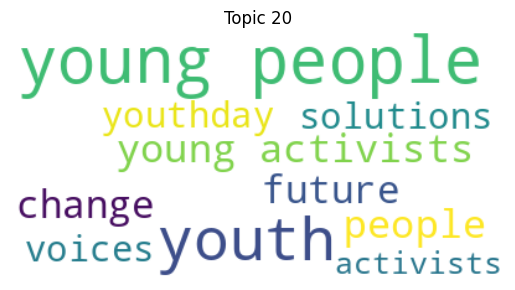

In [85]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Select a topic
topic_id = 20

# Get words and weights
topic_words = dict(topic_model.get_topic(topic_id))

# Create word cloud
wc = WordCloud(background_color="white")
wc.generate_from_frequencies(topic_words)

# Plot
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"Topic {topic_id}")
plt.show()

## Visualize Topic Hierarchy
The topics that were created can be hierarchically reduced. In order to understand the potential hierarchical structure of the topics, we can use scipy.cluster.hierarchy to create clusters and visualize how they relate to one another. This might help selecting an appropriate nr_topics when reducing the number of topics that you have created.

In [86]:
topic_model.visualize_hierarchy()

# Improving BERTopic

We can improve our topic model in several ways. These include reducing the number of topics, refining how topics are represented, and incorporating additional information such as annotated data. Before making any changes, however, we first need to identify where the model may be underperforming.

Potential issues to look for include topics that overlap in meaning, topics that are too broad or too specific, and topics that are difficult to interpret. We may also observe that some topics contain noisy or loosely related documents, suggesting that the clustering is not fully coherent. Identifying these issues allows us to make more targeted adjustments, rather than modifying the model arbitrarily.

## Topic Reduction

One common issue is that the model may generate too many topics, some of which capture very similar or overlapping content. This can make the results harder to interpret, as related themes are split across multiple topics rather than being grouped together. In such cases, topic reduction can be used to merge similar topics into broader clusters. This helps simplify the structure of the model, making it easier to interpret, although the resulting topics may still require further inspection.

To decide whether we should reduce the topics, we can inspect the heatmap.
If multiple topics are highliy similar, this suggests redundancy and indicates that topic reduction may be appropriate

In [87]:
topic_model.visualize_heatmap()

Topic reduction modifies the model in place. To compare the model before and after reduction, we need to create a copy of the original model before applying the reduction step.

In [88]:
import copy
original_model = copy.deepcopy(topic_model)


In [42]:
# Reducing Topics

# Reduce the number of topics
reduced_model = topic_model.reduce_topics(docs, nr_topics=30)

# Inspect the new topics
reduced_model.get_topic_info()

2026-04-07 11:23:04,135 - BERTopic - Topic reduction - Reducing number of topics
2026-04-07 11:23:04,156 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 11:23:37,393 - BERTopic - Representation - Completed ✓
2026-04-07 11:23:37,396 - BERTopic - Topic reduction - Reduced number of topics from 121 to 30


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2254,-1_rights_human_amp_human rights,"[rights, human, amp, human rights, humanrights...",[climatechange threatens peoples livelihoods c...
1,0,800,0_torture_migrants_standup4migrants_un,"[torture, migrants, standup4migrants, un, vict...",[srilanka torture prevention body concludes it...
2,1,582,1_civilians_syria_yemen_un,"[civilians, syria, yemen, un, afghanistan, amp...",[syria un human rights chief zeid calls on eac...
3,2,447,2_women_lgbti_gender_womens,"[women, lgbti, gender, womens, violence, equal...",[we must all stand together to build a future ...
4,3,425,3_human rights_human_rights_council,"[human rights, human, rights, council, un, glo...",[the un human rights council is about to start...
5,4,362,4_offices_work_support_work standup4humanrights,"[offices, work, support, work standup4humanrig...",[has donated 32m to support our offices humanr...
6,5,341,5_fightracism_racism_racial discrimination_dis...,"[fightracism, racism, racial discrimination, d...",[fightracism with the international decade for...
7,6,306,6_covid19_pandemic_health_response,"[covid19, pandemic, health, response, covid19 ...",[covid19 is a public health emergency that is ...
8,7,296,7_release_experts_belarus_un,"[release, experts, belarus, un, egypt, hrcttee...",[un hrcttee finds belarus violated iccpr by re...
9,8,295,8_declaration_universal declaration_humanright...,"[declaration, universal declaration, humanrigh...",[all human beings are born free and equal in d...


In [44]:
len(reduced_model.get_topic_info())

30

In [45]:
len(original_model.get_topic_info())

121

#Comparing Original and Reduced Model

We can inpect side-by-side topic tables

In [47]:
orig_topics = original_model.get_topic_info()
red_topics  = reduced_model.get_topic_info()

print(orig_topics.head(10))
print(red_topics.head(10))

   Topic  Count                                               Name  \
0     -1   2254                   -1_human_human rights_rights_amp   
1      0    207      0_standup4migrants_migrants_migration_migrant   
2      1    190             1_myanmar_rohingya_military_bangladesh   
3      2    167           2_lgbti_love_identity_sexual orientation   
4      3    145          3_torture_prevention_victims_illtreatment   
5      4    123  4_humanrightsday_pledge_stand_standup4humanrights   
6      5    121          5_hlpf_globalgoals_2030agenda_development   
7      6    114               6_guatemala_colombia_defenders_chile   
8      7    106           7_womens_women_gender_generationequality   
9      8    103  8_fightracism_racism_racial discrimination_dis...   

                                      Representation  \
0  [human, human rights, rights, amp, humanrights...   
1  [standup4migrants, migrants, migration, migran...   
2  [myanmar, rohingya, military, bangladesh, retu...   
3  [l

We can also inspect the mapping between the original and reduced models to identify which topics have been merged. This will help us compare specific topics

In [48]:
reduced_model.topic_mapper_.get_mappings()

{np.int64(-1): np.int64(-1),
 np.int64(0): np.int64(12),
 np.int64(1): np.int64(17),
 np.int64(2): np.int64(17),
 np.int64(3): np.int64(12),
 np.int64(4): np.int64(12),
 np.int64(5): np.int64(16),
 np.int64(6): np.int64(25),
 np.int64(7): np.int64(1),
 np.int64(8): np.int64(26),
 np.int64(9): np.int64(23),
 np.int64(10): np.int64(1),
 np.int64(11): np.int64(10),
 np.int64(12): np.int64(9),
 np.int64(13): np.int64(22),
 np.int64(14): np.int64(13),
 np.int64(15): np.int64(13),
 np.int64(16): np.int64(4),
 np.int64(17): np.int64(2),
 np.int64(18): np.int64(4),
 np.int64(19): np.int64(4),
 np.int64(20): np.int64(9),
 np.int64(21): np.int64(0),
 np.int64(22): np.int64(4),
 np.int64(23): np.int64(4),
 np.int64(24): np.int64(17),
 np.int64(25): np.int64(7),
 np.int64(26): np.int64(16),
 np.int64(27): np.int64(16),
 np.int64(28): np.int64(0),
 np.int64(29): np.int64(0),
 np.int64(30): np.int64(14),
 np.int64(31): np.int64(10),
 np.int64(32): np.int64(10),
 np.int64(33): np.int64(0),
 np.int64(

In [57]:
from IPython.display import display

print("Original topics (before reduction):")
print("Topic 0:", original_model.get_topic(0))
print("Topic 3:", original_model.get_topic(3))
print("Topic 4:", original_model.get_topic(4))

print("\nReduced topic:")
print("Topic 12:", reduced_model.get_topic(12))

Original topics (before reduction):
Topic 0: [('standup4migrants', np.float64(0.07205490412908142)), ('migrants', np.float64(0.05062311669813669)), ('migration', np.float64(0.05042504607813725)), ('migrant', np.float64(0.04033667884067981)), ('asylum', np.float64(0.03125306101789569)), ('refugee', np.float64(0.029128549517523538)), ('story', np.float64(0.025672172995866178)), ('refugees', np.float64(0.020884728926906477)), ('stories', np.float64(0.017442888147321)), ('border', np.float64(0.01718162230633099))]
Topic 3: [('torture', np.float64(0.13660025010099816)), ('prevention', np.float64(0.03815833914546664)), ('victims', np.float64(0.03549511024159144)), ('illtreatment', np.float64(0.03453509331062144)), ('body', np.float64(0.034146437373079486)), ('endtorture', np.float64(0.02621895978312435)), ('detention', np.float64(0.026116602389423735)), ('prisons', np.float64(0.02584698404249302)), ('fund', np.float64(0.02472836880240246)), ('liberty', np.float64(0.023416197721131984))]
Topi

In [54]:
original_model.visualize_topics()

In [56]:
reduced_model.visualize_topics()

## Fine Tuning
Another way to improve our results is to fine-tune our model. Fine-tuning refers to adjusting the topic model to improve the quality and interpretability of the topics it produces. Rather than rebuilding the model from scratch, we refine its outputs by modifying how topics are represented or by incorporating additional information. This allows us to better align the model with the structure of the data or with specific research goals.


In practice, fine-tuning can take several forms. For example, we may adjust how topics are grouped, refine their representations, or incorporate annotated data to guide the model towards more meaningful distinctions. These steps allow us to move from a purely unsupervised model to one that reflects more domain-specific knowledge.

### Guided Topic Modelling
One way to fine-tune a topic model is to guide it using domain knowledge. This can be done by specifying sets of seed words that represent themes we expect to find in the data. The model then uses these seed words to steer the formation of topics, resulting in more meaningful and interpretable clusters.

In [89]:
# Define Seed Topics:
seed_topic_list = [
    ["syria", "conflict", "civilians"],
    ["covid-19", "pandemic", "public health"],
    ["gender equality", "women", "rights"],
    ["climate change", "environment", "emissions"],
    ["torture", "detention", "ill-treatment"]
]

In [90]:
# Create Model with Seeds
topic_model_seeded = BERTopic(
    embedding_model="all-mpnet-base-v2",
    seed_topic_list=seed_topic_list,
    calculate_probabilities=True,
    verbose=True
)

In [91]:
# Fit Model (do not run without a GPU)
topics, probs = topic_model_seeded.fit_transform(docs)

2026-04-07 11:51:50,848 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/249 [00:00<?, ?it/s]

2026-04-07 11:52:30,206 - BERTopic - Embedding - Completed ✓
2026-04-07 11:52:30,207 - BERTopic - Guided - Find embeddings highly related to seeded topics.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-07 11:52:30,308 - BERTopic - Guided - Completed ✓
2026-04-07 11:52:30,309 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 11:52:49,662 - BERTopic - Dimensionality - Completed ✓
2026-04-07 11:52:49,663 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 11:52:57,394 - BERTopic - Cluster - Completed ✓
2026-04-07 11:52:57,400 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 11:52:57,654 - BERTopic - Representation - Completed ✓


In [93]:
print("Original:", len(original_model.get_topic_info()))
print("Reduced:", len(reduced_model.get_topic_info()))
print("Fine-tuned:", len(topic_model_seeded.get_topic_info()))

Original: 121
Reduced: 30
Fine-tuned: 165


In [94]:
topic_model_seeded.visualize_topics()

Reduction controls the number of topics.
Fine-tuning controls the meaning of topics.

## **Tasks**

**1) Concept-based comparison**

Use find_topics() to explore how each model represents a concept (e.g. "torture", "climate", "covid").

Do the returned topics relate to the concept?
Are they more relevant in the fine-tuned model compared to the original and reduced models?

**2) Compare topic representations**

Select 2–3 topics and examine their top words across models.

Are the words more coherent in the fine-tuned model?
Do topics appear more specific or meaningful?

**3) Examine noise (Topic -1)**

Compare Topic -1 across the three models.

Does the amount of noise change?
Does fine-tuning reduce or redistribute noise?

**4) Compare visualisations**

Use different visualisation methods (e.g. visualize_topics(), visualize_heatmap(), visualize_barchart()).

Do you observe clearer groupings in any model?
Are topics more or less clustered?
**Reminder** Make sure you use original_model for the initial model, as topic_model was updated during topic reduction.

## Other Ways to Refine Topics

###Improving topic representation
Using representation models (e.g. KeyBERT-inspired) to surface more meaningful words

###Adjusting the vectorizer
Removing very common or generic words (e.g. “photo”, “thank”)

###Changing embeddings or clustering parameters
Affecting how topics are formed and separated

# The End